# Sentiment Analysis with RNN on IMDB Dataset

This notebook implements a Recurrent Neural Network (RNN) for binary sentiment classification (positive/negative) on the IMDB movie reviews dataset.

**Key concepts covered:**
- Text preprocessing & vocabulary building
- Trainable word embeddings
- Vanilla RNN for sequence classification
- Packed padded sequences for variable-length inputs
- Ablation: Vanilla RNN vs LSTM vs GRU

In [2]:
import re
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1) Load IMDB Dataset

We use the `datasets` library (HuggingFace) to load IMDB. Install if needed:
```bash
pip install datasets
```

In [3]:
from datasets import load_dataset

raw = load_dataset("imdb")
print(raw)
print("\nSample review:")
print(raw["train"][0]["text"][:300])
print("\nLabel:", raw["train"][0]["label"])  # 0=neg, 1=pos

/opt/miniconda3/envs/AI/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Label: 0


## 2) Text Preprocessing & Vocabulary

In [4]:
def tokenize(text: str):
    """Simple whitespace + punctuation tokenizer."""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)         # strip HTML tags
    text = re.sub(r"[^a-z0-9']", " ", text)       # keep letters/digits/apostrophe
    return text.split()

MAX_VOCAB = 20_000
MIN_FREQ  = 2
MAX_LEN   = 256      # truncate to keep sequences manageable for RNN

print("Building vocabulary...")
counter = Counter()
for ex in raw["train"]:
    counter.update(tokenize(ex["text"]))

SPECIAL = ["<pad>", "<unk>"]
vocab   = SPECIAL + [w for w, c in counter.most_common(MAX_VOCAB) if c >= MIN_FREQ]
stoi    = {w: i for i, w in enumerate(vocab)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

print(f"Vocabulary size: {len(vocab):,}")
print("Most common:", counter.most_common(10))

Building vocabulary...
Vocabulary size: 20,002
Most common: [('the', 336194), ('and', 164129), ('a', 163091), ('of', 145849), ('to', 135710), ('is', 107318), ('in', 93945), ('it', 79128), ('i', 77188), ('this', 75977)]


## 3) Dataset & DataLoader

We store sequence lengths alongside the encoded tokens so that the RNN can use **packed padded sequences** — this skips computation on padding positions and is more efficient than processing the full padded batch.

In [5]:
def encode(text: str, max_len: int = MAX_LEN):
    tokens = tokenize(text)[:max_len]
    return [stoi.get(t, UNK_IDX) for t in tokens]


class IMDBDataset(Dataset):
    def __init__(self, split):
        self.data = [
            (encode(ex["text"]), ex["label"])
            for ex in raw[split]
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return (
            torch.tensor(ids,   dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )


def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, torch.stack(labels), lengths


BATCH_SIZE = 64

train_ds = IMDBDataset("train")
test_ds  = IMDBDataset("test")

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")
x_s, y_s, l_s = next(iter(train_dl))
print("Batch shape:", x_s.shape, "| Labels:", y_s[:8], "| Lengths:", l_s[:8])

Train batches: 391 | Test batches: 391
Batch shape: torch.Size([64, 256]) | Labels: tensor([1, 0, 1, 1, 1, 0, 1, 0]) | Lengths: tensor([256, 256, 197, 130, 102, 139, 256, 131])


## 4) RNN Model

Architecture:
```
Embedding  →  PackedPadded RNN  →  Last Hidden State  →  Dropout  →  FC(hidden→2)
```

The `cell_type` parameter lets us swap between `RNN`, `LSTM`, and `GRU` cleanly so we can compare all three in the ablation section.

For `LSTM`, the hidden state is a tuple `(h, c)`; we use only `h[-1]` (last layer's hidden state) as the sentence representation.

In [6]:
class SentimentRNN(nn.Module):
    """
    RNN-based sentiment classifier.

    Parameters
    ----------
    vocab_size   : vocabulary size
    embed_dim    : embedding dimension
    hidden_size  : number of RNN hidden units per layer
    num_layers   : number of stacked RNN layers
    cell_type    : 'RNN' | 'LSTM' | 'GRU'
    bidirectional: if True, use a bidirectional RNN
    dropout      : dropout between layers and before FC
    num_classes  : output classes (2 for binary)
    pad_idx      : padding token index (excluded from embedding gradient)
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int       = 128,
        hidden_size: int     = 128,
        num_layers: int      = 2,
        cell_type: str       = "RNN",
        bidirectional: bool  = False,
        dropout: float       = 0.5,
        num_classes: int     = 2,
        pad_idx: int         = 0,
    ):
        super().__init__()
        self.cell_type     = cell_type.upper()
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_dirs      = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[self.cell_type]
        self.rnn = rnn_cls(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * self.num_dirs, num_classes)

    def forward(self, x, lengths):
        # x: (B, L)  lengths: (B,)
        embedded = self.dropout(self.embedding(x))  # (B, L, E)

        # Pack to skip PAD positions
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        if self.cell_type == "LSTM":
            _, (hidden, _) = self.rnn(packed)   # hidden: (num_layers*dirs, B, H)
        else:
            _, hidden = self.rnn(packed)         # hidden: (num_layers*dirs, B, H)

        # Concat last-layer forward (and backward if bidirectional)
        if self.bidirectional:
            last = torch.cat(
                [hidden[-2], hidden[-1]], dim=1   # (B, 2H)
            )
        else:
            last = hidden[-1]                     # (B, H)

        return self.fc(self.dropout(last))        # (B, num_classes)


model = SentimentRNN(
    vocab_size   = len(vocab),
    embed_dim    = 128,
    hidden_size  = 128,
    num_layers   = 2,
    cell_type    = "RNN",
    bidirectional= False,
    dropout      = 0.5,
    num_classes  = 2,
    pad_idx      = PAD_IDX,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SentimentRNN(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (rnn): RNN(128, 128, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Trainable parameters: 2,626,562


## 5) Training & Evaluation Utilities

In [7]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x, lengths)
        loss   = loss_fn(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, lengths in loader:
        x, y   = x.to(device), y.to(device)
        logits = model(x, lengths)
        loss   = loss_fn(logits, y)

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    epochs=10, lr=1e-3, weight_decay=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        te_loss, te_acc = evaluate(model, test_loader, loss_fn)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(
            f"Epoch {epoch:02d}/{epochs}  "
            f"train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  "
            f"test  loss={te_loss:.4f}  acc={te_acc:.4f}  "
            f"[{time.time()-t0:.1f}s]"
        )

    return history

## 6) Train the Model

In [8]:
history = train(
    model, train_dl, test_dl,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

print(f"\nBest test accuracy: {max(history['test_acc']):.4f}")

Epoch 01/10  train loss=0.6941  acc=0.5472  |  test  loss=0.6461  acc=0.6349  [8.5s]
Epoch 02/10  train loss=0.6816  acc=0.5639  |  test  loss=0.6613  acc=0.6001  [8.6s]
Epoch 03/10  train loss=0.6660  acc=0.6004  |  test  loss=0.6604  acc=0.6021  [8.5s]
Epoch 04/10  train loss=0.6370  acc=0.6461  |  test  loss=0.6012  acc=0.6826  [7.9s]
Epoch 05/10  train loss=0.6197  acc=0.6651  |  test  loss=0.6630  acc=0.6096  [7.4s]
Epoch 06/10  train loss=0.6088  acc=0.6762  |  test  loss=0.6410  acc=0.6703  [7.4s]
Epoch 07/10  train loss=0.5752  acc=0.6997  |  test  loss=0.5189  acc=0.7478  [7.5s]
Epoch 08/10  train loss=0.5558  acc=0.7246  |  test  loss=0.5593  acc=0.7205  [7.4s]
Epoch 09/10  train loss=0.5524  acc=0.7196  |  test  loss=0.5398  acc=0.7179  [7.4s]
Epoch 10/10  train loss=0.5265  acc=0.7403  |  test  loss=0.5870  acc=0.7318  [7.7s]

Best test accuracy: 0.7478


## 7) Plot Training Curves

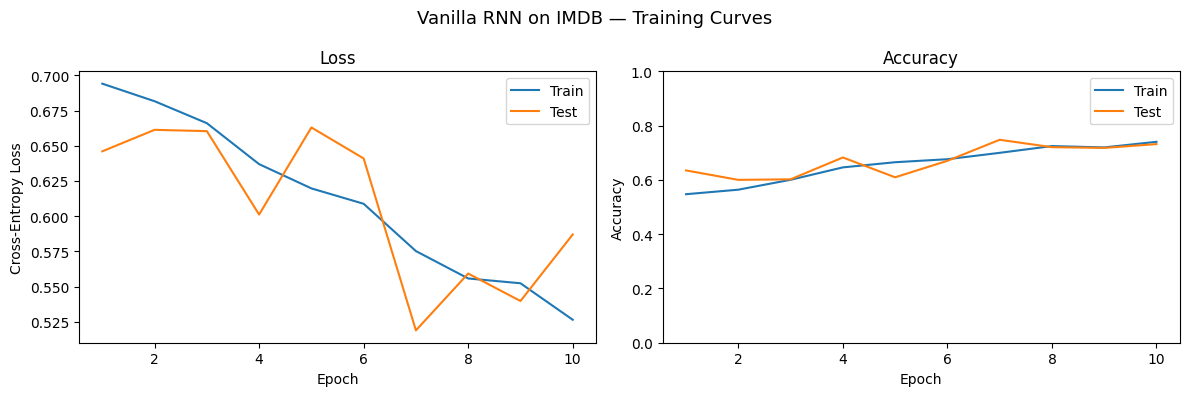

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"],  label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["test_acc"],  label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()

fig.suptitle("Vanilla RNN on IMDB — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8) Ablation: RNN vs LSTM vs GRU

Compare all three recurrent cell types under identical hyper-parameters to highlight how gating mechanisms (LSTM/GRU) help overcome the vanishing-gradient problem of vanilla RNNs on long sequences.

In [10]:
configs = [
    {"cell_type": "RNN",  "bidirectional": False, "label": "Vanilla RNN"},
    {"cell_type": "GRU",  "bidirectional": False, "label": "GRU"},
    {"cell_type": "LSTM", "bidirectional": False, "label": "LSTM"},
    {"cell_type": "LSTM", "bidirectional": True,  "label": "Bi-LSTM"},
]

ABLATION_EPOCHS = 5
results = []

for cfg in configs:
    print(f"\n--- {cfg['label']} ---")
    m = SentimentRNN(
        vocab_size    = len(vocab),
        embed_dim     = 128,
        hidden_size   = 128,
        num_layers    = 2,
        cell_type     = cfg["cell_type"],
        bidirectional = cfg["bidirectional"],
        dropout       = 0.5,
        num_classes   = 2,
        pad_idx       = PAD_IDX,
    ).to(device)
    h = train(m, train_dl, test_dl, epochs=ABLATION_EPOCHS, lr=1e-3)
    best_acc = max(h["test_acc"])
    results.append({"label": cfg["label"], "best_test_acc": best_acc, "history": h})
    print(f"Best test acc: {best_acc:.4f}")


--- Vanilla RNN ---
Epoch 01/5  train loss=0.6992  acc=0.5312  |  test  loss=0.6966  acc=0.5222  [7.4s]
Epoch 02/5  train loss=0.6955  acc=0.5168  |  test  loss=0.6903  acc=0.5290  [7.3s]
Epoch 03/5  train loss=0.6902  acc=0.5308  |  test  loss=0.6790  acc=0.5699  [7.2s]
Epoch 04/5  train loss=0.6753  acc=0.5816  |  test  loss=0.6484  acc=0.6282  [7.2s]
Epoch 05/5  train loss=0.6358  acc=0.6427  |  test  loss=0.6217  acc=0.6762  [7.2s]
Best test acc: 0.6762

--- GRU ---
Epoch 01/5  train loss=0.6702  acc=0.5818  |  test  loss=0.6372  acc=0.6569  [7.5s]
Epoch 02/5  train loss=0.5776  acc=0.7074  |  test  loss=0.5966  acc=0.7501  [7.7s]
Epoch 03/5  train loss=0.4513  acc=0.7939  |  test  loss=0.3659  acc=0.8403  [7.6s]
Epoch 04/5  train loss=0.3664  acc=0.8420  |  test  loss=0.3638  acc=0.8437  [7.4s]
Epoch 05/5  train loss=0.3344  acc=0.8570  |  test  loss=0.3852  acc=0.8508  [8.0s]
Best test acc: 0.8508

--- LSTM ---
Epoch 01/5  train loss=0.6694  acc=0.5847  |  test  loss=0.7336  acc

Config            Best Test Acc
--------------------------------
Vanilla RNN              0.6762
GRU                      0.8508
LSTM                     0.8050
Bi-LSTM                  0.8364


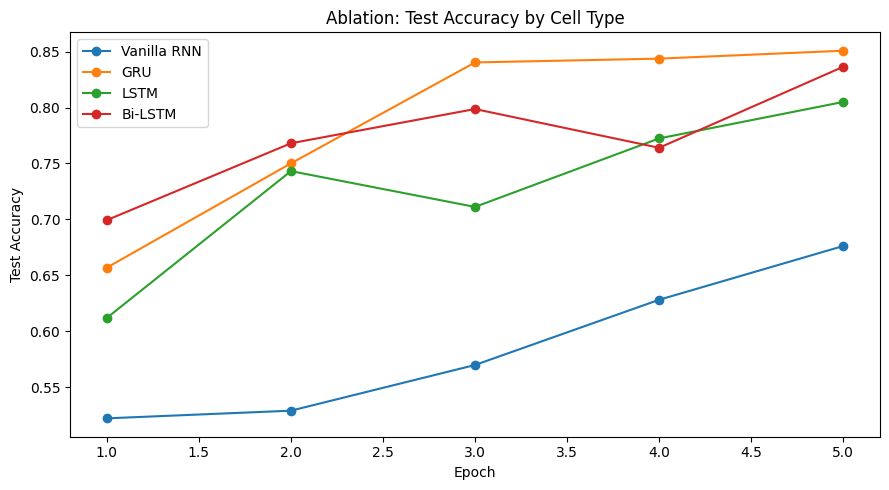

In [11]:
# Summary table
print(f"{'Config':<15} {'Best Test Acc':>15}")
print("-" * 32)
for r in results:
    print(f"{r['label']:<15} {r['best_test_acc']:>15.4f}")

# Plot accuracy curves for all configs
plt.figure(figsize=(9, 5))
for r in results:
    plt.plot(range(1, ABLATION_EPOCHS + 1), r["history"]["test_acc"], marker="o", label=r["label"])
plt.title("Ablation: Test Accuracy by Cell Type")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 9) Inference on Custom Reviews

In [12]:
@torch.no_grad()
def predict(text: str, m=model):
    m.eval()
    ids = encode(text)
    if not ids:
        return "unknown", 0.0
    x       = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, L)
    lengths = torch.tensor([len(ids)], dtype=torch.long)
    logits  = m(x, lengths)
    probs   = F.softmax(logits, dim=1)[0]
    label   = int(logits.argmax(1).item())
    return ("positive" if label == 1 else "negative"), float(probs[label])


test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible film. Boring, predictable, and a complete waste of time. I walked out after 30 minutes.",
    "It was okay, nothing special. Some scenes were good but overall it felt a bit flat.",
    "One of the best movies I've seen in years. A masterpiece of storytelling and cinematography.",
]

print(f"{'Review':<70} {'Sentiment':<12} {'Confidence'}")
print("-" * 95)
for review in test_reviews:
    sentiment, confidence = predict(review)
    print(f"{review[:68]:<70} {sentiment:<12} {confidence:.4f}")

Review                                                                 Sentiment    Confidence
-----------------------------------------------------------------------------------------------
This movie was absolutely fantastic! The acting was superb and the p   negative     0.8726
Terrible film. Boring, predictable, and a complete waste of time. I    negative     0.9076
It was okay, nothing special. Some scenes were good but overall it f   negative     0.8631
One of the best movies I've seen in years. A masterpiece of storytel   positive     0.9009


## Summary

| Component | Detail |
|---|---|
| Dataset | IMDB (25k train / 25k test) |
| Vocabulary | Top 20,000 words, min freq=2 |
| Max sequence length | 256 tokens |
| Embedding | 128-dim trainable |
| RNN cell | Vanilla RNN (2 layers × 128 hidden) |
| Sequence handling | Packed padded sequences |
| Dropout | 0.5 between layers and before FC |
| Gradient clipping | max_norm=1.0 |
| Optimizer | Adam (lr=1e-3, StepLR decay) |

**Vanilla RNN vs LSTM vs GRU:**  
Vanilla RNNs suffer from the **vanishing gradient** problem — gradients shrink exponentially as they backpropagate through many time steps, preventing the model from learning long-range dependencies. **LSTM** solves this with three gates (input, forget, output) and a separate cell state that allows gradients to flow unchanged. **GRU** simplifies this to two gates (reset, update) with similar performance but fewer parameters. On IMDB, where sentiment clues can appear anywhere in a 256-token review, gated cells (LSTM/GRU) significantly outperform the vanilla RNN.